In [2]:
import datasets
import torchvision.transforms.v2 as transforms
from torch.utils.data import DataLoader 


# SET PYTHONPATH to the parent directory 
import sys
import os
import glob
import pandas as pd
sys.path.append(os.path.abspath(".."))

In [ ]:
import torch
import yaml

In [13]:
k_size = []
test_accs = []
val_45_accs = []
val_accs = []
val_rd_accs = []
epoch_time = []

dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-mnistrottest-k*/*")

for dir in dirs:
    with open(f"{dir}/hparams.yaml", 'r') as f:
        hparams = yaml.safe_load(f)
        tmp_df = pd.read_csv(f"{dir}/metrics.csv")
        if 'test_acc' not in tmp_df.columns:
            print(f"No test accuracy found for {dir}")
            continue
        k_size.append(hparams['m_param']['filter_size'])
        test_acc = tmp_df['test_acc'].dropna().values
        val_45 = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_45_acc']
        val_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_acc']
        val_rd_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_rd_acc']
        if 'train_epoch_time' in tmp_df.columns:
            epoch_time.append(tmp_df['train_epoch_time'].median())
        else:
            epoch_time.append(None)

        test_accs.append(test_acc[0])
        val_45_accs.append(val_45)
        val_accs.append(val_acc)
        val_rd_accs.append(val_rd_acc)
        assert len(test_acc) == 1, "More than one accuracy value found"

df = pd.DataFrame({"filter_size": k_size, "test_acc": test_accs, "val_45_acc": val_45_accs, "val_acc": val_accs, "val_rd_acc": val_rd_accs, "train_epoch_time": epoch_time}).sort_values("filter_size", ascending=False)

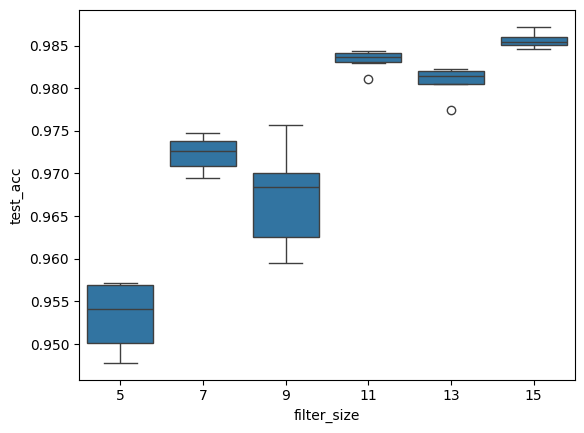

In [14]:
# make box plots with axis x - filter size and y - test accuracy
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x="filter_size", y="test_acc", data=df)
plt.show()


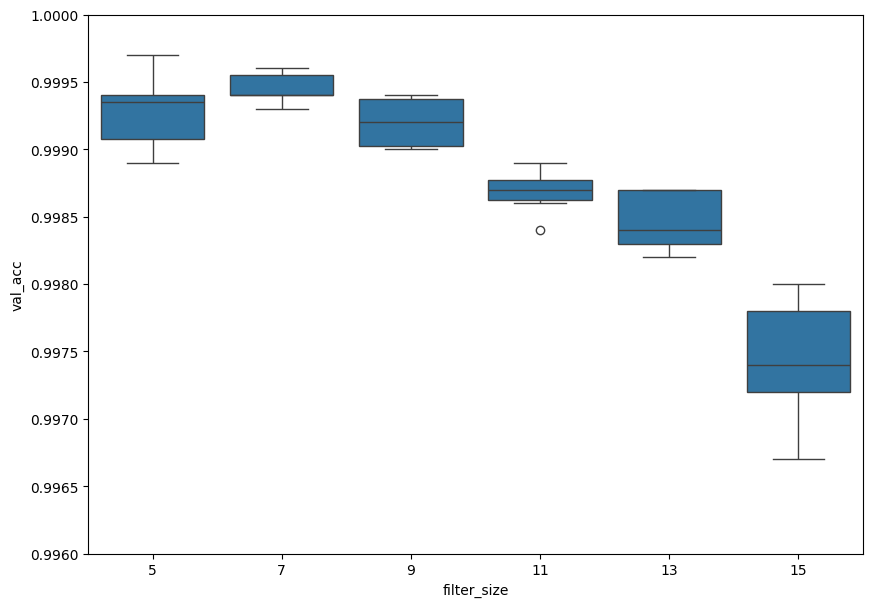

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(x="filter_size", y="val_acc", data=df, )
ax.set_ylim(0.996, 1.0)
plt.show()

<Axes: xlabel='filter_size', ylabel='val_45_acc'>

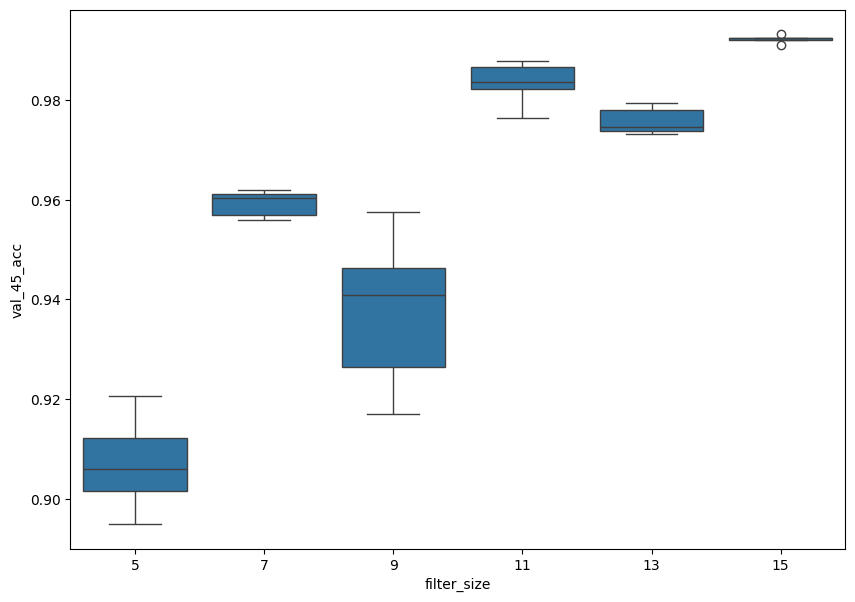

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(x="filter_size", y="val_45_acc", data=df, ax=ax)

<Axes: xlabel='filter_size', ylabel='val_rd_acc'>

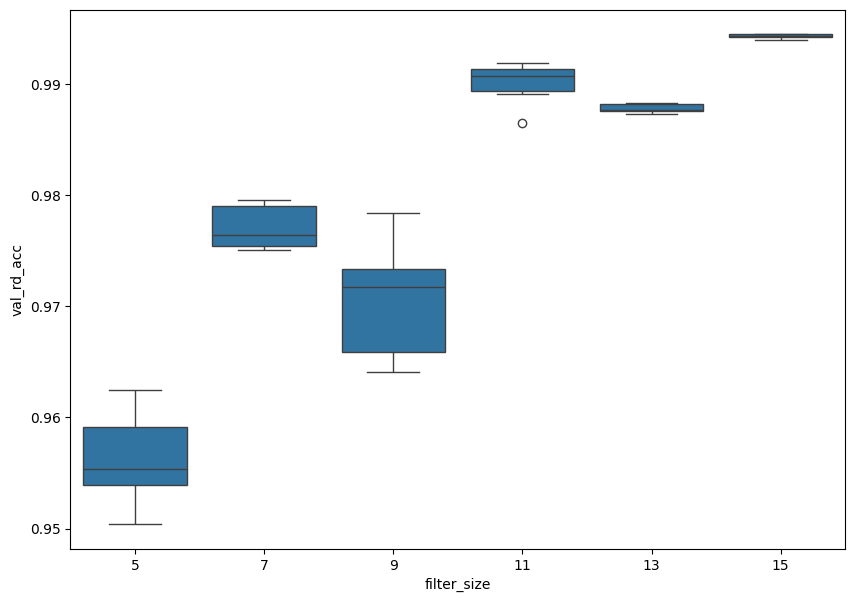

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(10, 7))
sns.boxplot(x="filter_size", y="val_rd_acc", data=df, ax=ax)


In [18]:
df[['filter_size', 'train_epoch_time']].dropna()

,filter_size,train_epoch_time
17,15,184.015564
20,15,80.386925
19,15,150.959106
15,13,148.432358
12,13,75.689987
14,13,75.826073
32,11,160.047424
31,11,71.191116
29,11,70.686722
1,9,68.108063


/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11/6ca9e30c1e125efd706cf16cd3242c511032b62c-122
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11/6ca9e30c1e125efd706cf16cd3242c511032b62c-9
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11/6ca9e30c1e125efd706cf16cd3242c511032b62c-38
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11k11k9/a6490d03684fff31017350babf3ae3bf66d25b50-444
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11k11k9/f235dd37a71434c307ace3c133e45a86cf3d6620-122
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k11k11k9/a6490d03684fff31017350babf3ae3bf66d25b50-182
/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15k

<Axes: xlabel='filter_size', ylabel='test_acc'>

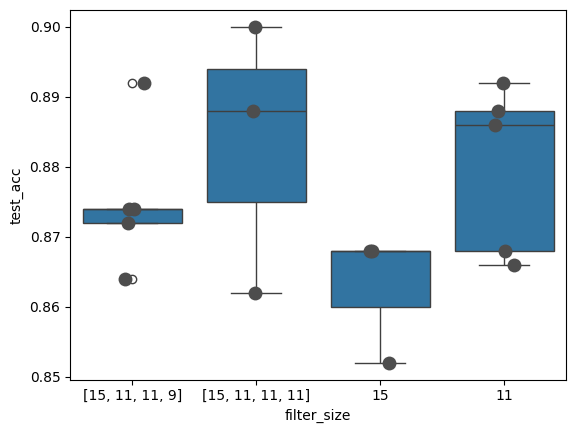

In [ ]:
k_size = []
test_accs = []
val_45_accs = []
val_accs = []
val_rd_accs = []

dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k*/*")

for dir in dirs:
    with open(f"{dir}/hparams.yaml", 'r') as f:
        print(dir)
        hparams = yaml.safe_load(f)
        tmp_df = pd.read_csv(f"{dir}/metrics.csv")
        if 'test_acc' not in tmp_df.columns:
            print(f"No test accuracy found for {dir}")
            continue
        k_size.append(str(hparams['m_param']['filter_size']))
        test_acc = tmp_df['test_acc'].dropna().values
        #val_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_acc']
        test_accs.append(test_acc[0])
        val_accs.append(val_acc)
        assert len(test_acc) == 1, "More than one accuracy value found"


df_hist = pd.DataFrame({"filter_size": k_size, "test_acc": test_accs, "val_acc": val_accs}).sort_values("filter_size", ascending=False)
sns.boxplot(x="filter_size", y="test_acc", data=df_hist, showfliers=True)
sns.stripplot(x="filter_size", y="test_acc", data=df_hist, size=10, color=".3", linewidth=0)


{'d_hparams': {'batch_size': 32}, 'dataset_name': 'ColorectalHistology', 'debug': False, 'early_stopping': 15, 'epochs': 50, 'input_shape': [32, 3, 128, 128], 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.1, 'milestones': [10, 15, 25]}, 'lr_name': 'MultiStepLR', 'm_param': {'in_channels': 3, 'init_channels': [8, 16, 32, 58], 'input_size': 150, 'learnable_radial_basis': 5, 'm_layers': 3, 'n_blocks': 4, 'num_classes': 8}, 'model_name': 'PrototypeOptimalInvCNN', 'optimizer_hparams': {'lr': 0.01525}, 'optimizer_name': 'AdamW', 'run_name': 'prototype-histology-radial', 'seed': 223}
{'d_hparams': {'batch_size': 32}, 'dataset_name': 'ColorectalHistology', 'debug': False, 'early_stopping': 15, 'epochs': 50, 'input_shape': [32, 3, 128, 128], 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.1, 'milestones': [10, 15, 25]}, 'lr_name': 'MultiStepLR', 'm_param': {'filter_size': 11, 'in_channels': 3, 'init_channels': 7, 'input_size': 150, 'learnable_radial_basis': 5, 'm_layers': 2, 'n_blocks': 4

<Axes: xlabel='learnable_radial', ylabel='test_acc'>

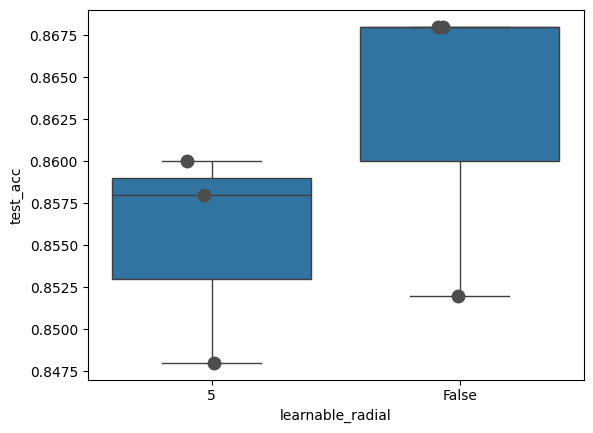

In [51]:
# Histology data
k_size = []
test_accs = []
train_accs = []
val_accs = []
radials = []

radial_dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-radial/*") + glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-histology-k15/*") 
for dir in radial_dirs: 
    hparams = yaml.safe_load(open(f"{dir}/hparams.yaml"))
    print(hparams)
    if 'filter_size' in hparams['m_param'] and hparams['m_param']['filter_size'] != 15: 
        continue
    tmp_df = pd.read_csv(f"{dir}/metrics.csv")
    if 'test_acc' not in tmp_df.columns:
        print(f"No test accuracy found for {dir}")
        continue
    test_acc = tmp_df['test_acc'].dropna().values
    #val_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_acc']
    test_accs.append(test_acc[0])
    val_accs.append(val_acc)
    assert len(test_acc) == 1, "More than one accuracy value found"
    if 'learnable_radial_basis' in hparams['m_param']:
        radials.append(str(hparams['m_param']['learnable_radial_basis']))
    else: 
        radials.append("False")
df = pd.DataFrame({
    "test_acc": test_accs,
    "val_acc": val_accs,
    "learnable_radial": radials
})

sns.boxplot(x="learnable_radial", y="test_acc", data=df, showfliers=True)
sns.stripplot(x="learnable_radial", y="test_acc", data=df, size=10, color=".3", linewidth=0)

{'d_hparams': {'batch_size': 128, 'data_dir': 'data', 'normalize': True, 'pad': 0, 'to_complex': False}, 'dataset_name': 'MnistRotTest', 'debug': False, 'early_stopping': 10, 'epochs': 35, 'input_shape': [128, 1, 64, 64], 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.1, 'milestones': [10, 15, 25]}, 'lr_name': 'MultiStepLR', 'm_param': {'filter_size': 11, 'in_channels': 1, 'init_channels': 4, 'input_size': 64, 'learnable_radial_basis': 5, 'num_classes': 10}, 'model_name': 'PrototypeOptimalInvCNN', 'optimizer_hparams': {'lr': 0.01525}, 'optimizer_name': 'AdamW', 'run_name': 'prototype-mnistrottest-radial', 'seed': 234}
{'d_hparams': {'batch_size': 128, 'data_dir': 'data', 'normalize': True, 'pad': 0, 'to_complex': False}, 'dataset_name': 'MnistRotTest', 'debug': False, 'early_stopping': 10, 'epochs': 35, 'input_shape': [128, 1, 64, 64], 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.1, 'milestones': [10, 15, 25]}, 'lr_name': 'MultiStepLR', 'm_param': {'filter_size': 11, 'in_channe

<Axes: xlabel='learnable_radial', ylabel='test_acc'>

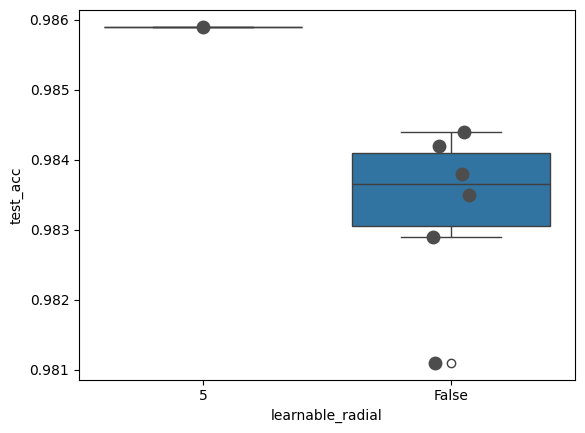

In [60]:
k_size = []
test_accs = []
val_45_accs = []
val_accs = []
val_rd_accs = []
radials = []

radial_dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-mnistrottest-radial/*")
non_radial_dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-mnistrottest-k11/*")

for dir in radial_dirs + non_radial_dirs:
    hparams = yaml.safe_load(open(f"{dir}/hparams.yaml"))
    print(hparams)
    tmp_df = pd.read_csv(f"{dir}/metrics.csv")
    if 'test_acc' not in tmp_df.columns:
        print(f"No test accuracy found for {dir}")
        continue
    test_acc = tmp_df['test_acc'].dropna().values
    #val_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_acc']
    test_accs.append(test_acc[0])
    val_accs.append(val_acc)
    assert len(test_acc) == 1, "More than one accuracy value found"
    if 'learnable_radial_basis' in hparams['m_param']:
        radials.append(str(hparams['m_param']['learnable_radial_basis']))
    else: 
        radials.append("False")
df = pd.DataFrame({
    "test_acc": test_accs,
    "val_acc": val_accs,
    "learnable_radial": radials
})

sns.boxplot(x="learnable_radial", y="test_acc", data=df, showfliers=True)
sns.stripplot(x="learnable_radial", y="test_acc", data=df, size=10, color=".3", linewidth=0)

{'augmentation': True, 'batch_size': 16, 'd_hparams': {'batch_size': 16, 'data_dir': 'data'}, 'dataset_name': 'RotMnist', 'debug': False, 'early_stopping': 15, 'epochs': 100, 'input_shape': [16, 1, 28, 28], 'interpolation': 'BILINEAR', 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.95}, 'lr_name': 'ExponentialLR', 'm_param': {'learnable_radial_basis': 3, 'num_classes': 10, 'scale_channels': 4}, 'model_name': 'PrototypeTiny', 'optimizer_hparams': {'lr': 0.01525, 'weight_decay': 0.05}, 'optimizer_name': 'AdamW', 'run_name': 'prototype-rotmnist', 'seed': 24}
{'augmentation': True, 'batch_size': 16, 'd_hparams': {'batch_size': 16, 'data_dir': 'data'}, 'dataset_name': 'RotMnist', 'debug': False, 'early_stopping': 15, 'epochs': 100, 'input_shape': [16, 1, 28, 28], 'interpolation': 'BILINEAR', 'label_smoothing': 0.0, 'lr_hparams': {'gamma': 0.95}, 'lr_name': 'ExponentialLR', 'm_param': {'learnable_radial_basis': 3, 'num_classes': 10, 'scale_channels': 4}, 'model_name': 'PrototypeTiny', 'op

<Axes: xlabel='learnable_radial', ylabel='test_acc'>

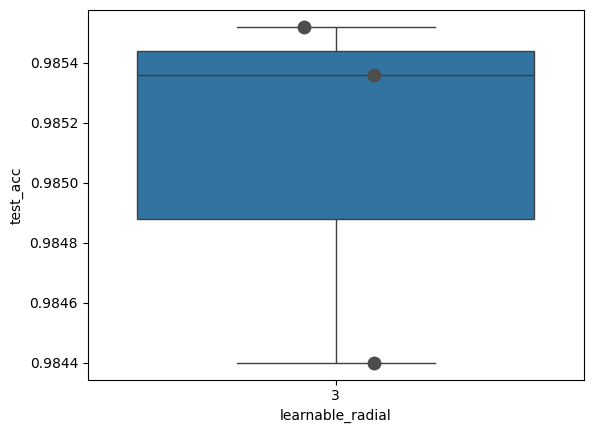

In [61]:
k_size = []
test_accs = []
val_45_accs = []
val_accs = []
val_rd_accs = []
radials = []

radial_dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-rotmnist-radial/*")
non_radial_dirs = glob.glob("/Users/karella/Projects/rotation-invariant-neural-networks/hippy2d/logs/csv/prototype-rotmnist/*")

for dir in radial_dirs + non_radial_dirs:
    hparams = yaml.safe_load(open(f"{dir}/hparams.yaml"))
    print(hparams)
    tmp_df = pd.read_csv(f"{dir}/metrics.csv")
    if 'test_acc' not in tmp_df.columns:
        print(f"No test accuracy found for {dir}")
        continue
    test_acc = tmp_df['test_acc'].dropna().values
    #val_acc = tmp_df.loc[tmp_df['val_acc'].idxmax()]['val_acc']
    test_accs.append(test_acc[0])
    val_accs.append(val_acc)
    assert len(test_acc) == 1, "More than one accuracy value found"
    if 'learnable_radial_basis' in hparams['m_param']:
        radials.append(str(hparams['m_param']['learnable_radial_basis']))
    else: 
        radials.append("False")
df = pd.DataFrame({
    "test_acc": test_accs,
    "val_acc": val_accs,
    "learnable_radial": radials
})

sns.boxplot(x="learnable_radial", y="test_acc", data=df, showfliers=True)
sns.stripplot(x="learnable_radial", y="test_acc", data=df, size=10, color=".3", linewidth=0)